In [2]:
library("dplyr")
library("pomp")

Warning message:
"package 'dplyr' was built under R version 4.4.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [52]:
ll_df <- read.csv("data/results.csv")
ll_df <- ll_df %>% filter(bEP >= -0.5 & bEP <= 1) %>% filter(loglik > -2300) -> ll_df

In [67]:
library("loess")


ERROR: Error in library("loess"): there is no package called 'loess'


In [ ]:
mcap_r <- mcap(ll_df$loglik, ll_df$bEP, level = 0.95, span = 0.75, Ngrid = 1000)

mle      <- mcap_r$mle
sm_ll_df <- mcap_r$fit
param    <- mcap_r$param
ci       <- mcap_r$ci

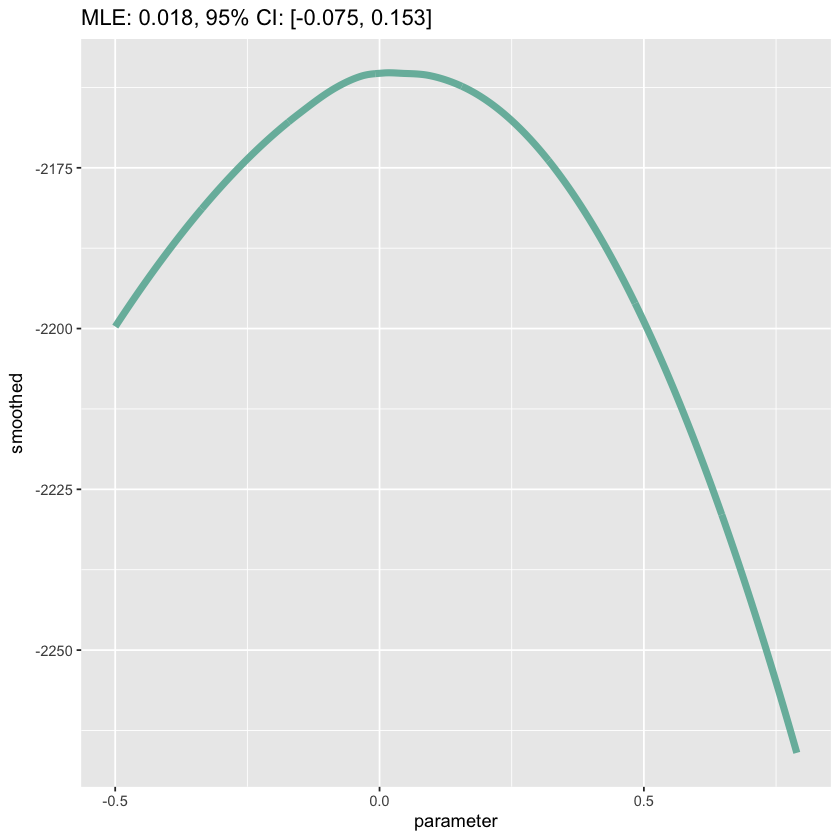

In [63]:
library("ggplot2")

#plot(x = sm_ll_df$parameter, y = sm_ll_df$smoothed, ylab = "loglik")
#+ theme(plot_background= element_rect(fill='lightblue', color='lightblue'))
title <- sprintf("MLE: %.3f, 95%% CI: [%.3f, %.3f]", mle, ci[1], ci[2])
ggplot(sm_ll_df, aes(x=parameter, y=smoothed)) +
  geom_line(color="#69b3a2", linewidth=2, alpha=0.9, linetype=1) +
  ggtitle(title)

In [48]:
cat(sprintf("MLE: %.3f, 95%% CI: [%.3f, %.3f]", mle, ci[1], ci[2]))

MLE: 0.018, 95% CI: [-0.075, 0.153]

In [47]:
ci[1]

[1] -0.07533124